In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──
np.random.seed(42)
tf.random.set_seed(42)


plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 10
})

# ── Hyperparameters ──
LATENT_DIM  = 32    
EPOCHS      = 50
BATCH_SIZE  = 256
LR          = 1e-3

print(f"Latent dimension   : {LATENT_DIM}  (compression ratio: {784/LATENT_DIM:.1f}×)")

Latent dimension   : 32  (compression ratio: 24.5×)


In [2]:

(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f"Raw train shape : {X_train_raw.shape}  — {X_train_raw.shape[0]:,} images of {X_train_raw.shape[1]}×{X_train_raw.shape[2]} px")
print(f"Raw test  shape : {X_test_raw.shape}")

X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

print(f"After preprocessing:")
print(f"  Train  : {X_train_flat.shape}  values in [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print(f"  Test   : {X_test_flat.shape}")
print(f"For autoencoders the TARGET = INPUT (unsupervised reconstruction).")

Raw train shape : (60000, 28, 28)  — 60,000 images of 28×28 px
Raw test  shape : (10000, 28, 28)
After preprocessing:
  Train  : (60000, 784)  values in [0.0, 1.0]
  Test   : (10000, 784)
For autoencoders the TARGET = INPUT (unsupervised reconstruction).


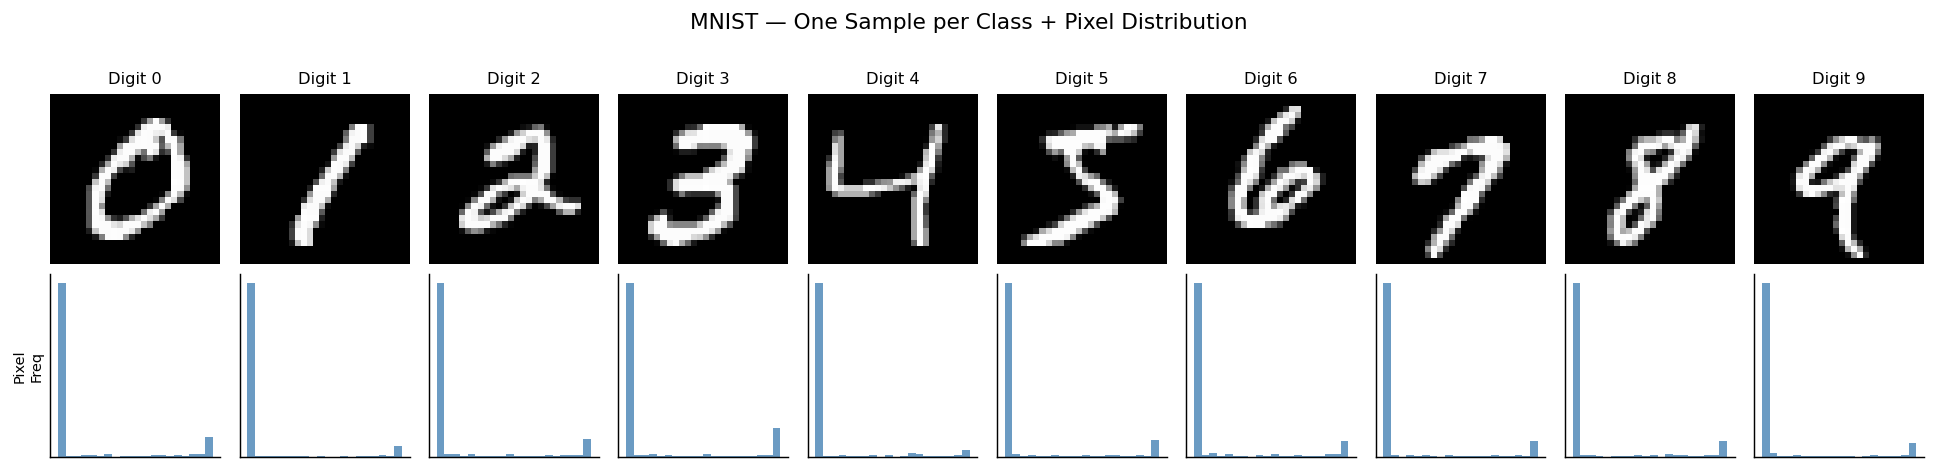

In [3]:
# ── Peek at the raw data ──
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for i in range(10):
    # One example per digit class (0–9)
    idx = np.where(y_train == i)[0][0]
    axes[0, i].imshow(X_train[idx], cmap='gray')
    axes[0, i].set_title(f'Digit {i}', fontsize=9)
    axes[0, i].axis('off')

    # Pixel intensity histogram
    axes[1, i].hist(X_train[idx].flatten(), bins=20,
                    color='steelblue', edgecolor='none', alpha=0.8)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[1, 0].set_ylabel('Pixel\nFreq', fontsize=8)
plt.suptitle('MNIST — One Sample per Class + Pixel Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ════════════════════════════════════════════════
#  ENCODER
# ════════════════════════════════════════════════
def build_encoder(latent_dim):
    """
    Compresses 784-dimensional input down to `latent_dim`.
    BatchNorm after each hidden layer stabilises training.
    """
    inp = keras.Input(shape=(784,), name='encoder_input')

    x = layers.Dense(256, name='enc_dense1')(inp)
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.Activation('relu', name='enc_relu1')(x)

    x = layers.Dense(128, name='enc_dense2')(x)
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.Activation('relu', name='enc_relu2')(x)

    x = layers.Dense(64, name='enc_dense3')(x)
    x = layers.BatchNormalization(name='enc_bn3')(x)
    x = layers.Activation('relu', name='enc_relu3')(x)

    # ── Bottleneck ──
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    return Model(inp, latent, name='Encoder')


# ════════════════════════════════════════════════
#  DECODER  (mirror of encoder)
# ════════════════════════════════════════════════
def build_decoder(latent_dim):
    """
    Reconstructs 784-dimensional output from `latent_dim`.
    Sigmoid output maps values back to [0, 1] pixel range.
    """
    inp = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(64, name='dec_dense1')(inp)
    x = layers.BatchNormalization(name='dec_bn1')(x)
    x = layers.Activation('relu', name='dec_relu1')(x)

    x = layers.Dense(128, name='dec_dense2')(x)
    x = layers.BatchNormalization(name='dec_bn2')(x)
    x = layers.Activation('relu', name='dec_relu2')(x)

    x = layers.Dense(256, name='dec_dense3')(x)
    x = layers.BatchNormalization(name='dec_bn3')(x)
    x = layers.Activation('relu', name='dec_relu3')(x)

    # ── Reconstruction layer ──
    # Sigmoid ensures output ∈ [0,1], matching normalised pixel values
    output = layers.Dense(784, activation='sigmoid', name='reconstruction')(x)

    return Model(inp, output, name='Decoder')


# ════════════════════════════════════════════════
#  FULL AUTOENCODER
# ════════════════════════════════════════════════
encoder = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM)

# Chain encoder → decoder
autoencoder_input  = keras.Input(shape=(784,), name='autoencoder_input')
encoded            = encoder(autoencoder_input)
decoded            = decoder(encoded)
autoencoder        = Model(autoencoder_input, decoded, name='Autoencoder')

# Compile
# Binary cross-entropy loss works well when pixels are in [0,1]
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy'
)

print("Autoencoder compiled successfully!")

Autoencoder compiled successfully!


In [5]:
print("ENCODER SUMMARY")
encoder.summary()

print("DECODER SUMMARY")
decoder.summary()

print("FULL AUTOENCODER SUMMARY")
autoencoder.summary()

total_params = autoencoder.count_params()
print(f"Compression ratio : 784 → {LATENT_DIM}  ({784/LATENT_DIM:.1f}× reduction)")
print(f"Total parameters  : {total_params:,}")

ENCODER SUMMARY


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_dense1 (Dense)                   │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn1 (BatchNormalization)         │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_relu1 (Activation)               │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_dense2 (Dense)                   │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn2 (BatchNormalization)         │ (None, 128)                 │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_relu2 (Activation)               │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_dense3 (Dense)                   │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn3 (BatchNormalization)         │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_relu3 (Activation)               │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 32)                  │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,984 (960.88 KB)

 Trainable params: 245,088 (957.38 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)       │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder (Functional)                 │ (None, 32)                  │         245,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder (Functional)                 │ (None, 784)                 │         246,736 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 492,720 (1.88 MB)

 Trainable params: 490,928 (1.87 MB)

 Non-trainable params: 1,792 (7.00 KB)

Compression ratio : 784 → 32  (24.5× reduction)
Total parameters  : 492,720


In [6]:
callbacks = [
    # Stop early if val_loss stops improving
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    # Reduce LR when plateauing
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_autoencoder.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    )
]

# For autoencoders: input = target (self-supervised reconstruction)
history = autoencoder.fit(
    X_train_flat, X_train_flat,          # X == y
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\n✓ Training complete — best epoch: {best_epoch}/{len(history.history['loss'])}")
print(f"  Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.2035 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1292 - val_loss: 0.1255 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1152 - val_loss: 0.1128 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1080 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1035 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1002 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0978 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0960 - val_loss: 0.0954 - learning_rate: 0.0010
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0945 - val_loss: 0.0937 - learning_rate: 0.0010


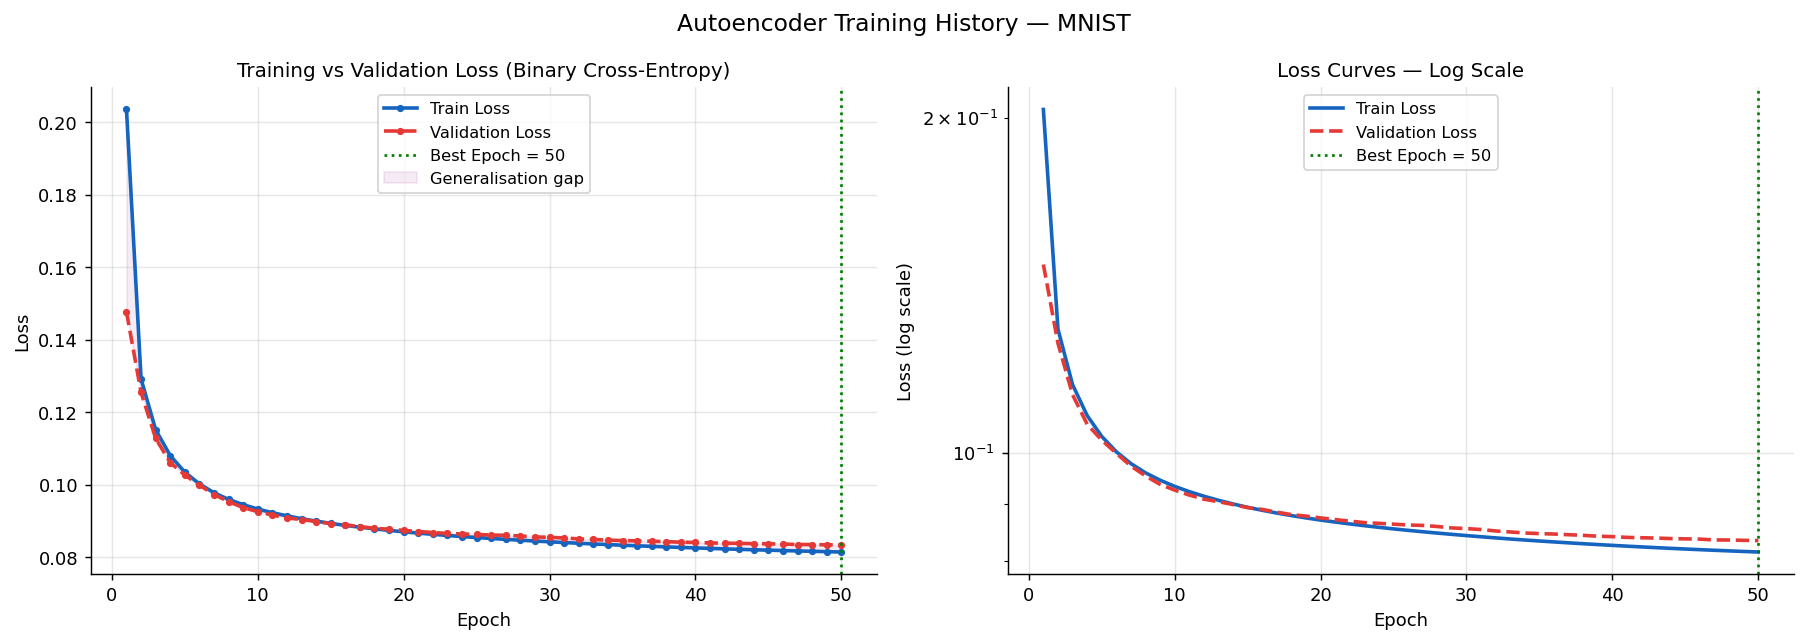

Initial train loss : 0.2035  →  Final: 0.0815  (↓ 60.0%)
Initial val   loss : 0.1477  →  Final: 0.0834


In [7]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: full loss curves ──
axes[0].plot(epochs_ran, train_loss, color='#1565C0', lw=2,
             marker='o', markersize=3, label='Train Loss')
axes[0].plot(epochs_ran, val_loss,   color='#E53935', lw=2,
             marker='o', markersize=3, linestyle='--', label='Validation Loss')
axes[0].axvline(best_epoch, color='green', lw=1.5, linestyle=':',
                label=f'Best Epoch = {best_epoch}')
axes[0].fill_between(epochs_ran, train_loss, val_loss,
                     alpha=0.08, color='purple', label='Generalisation gap')
axes[0].set_title('Training vs Validation Loss (Binary Cross-Entropy)', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)

# ── Right: log-scale to highlight convergence ──
axes[1].semilogy(epochs_ran, train_loss, color='#1565C0', lw=2, label='Train Loss')
axes[1].semilogy(epochs_ran, val_loss,   color='#E53935', lw=2,
                 linestyle='--', label='Validation Loss')
axes[1].axvline(best_epoch, color='green', lw=1.5, linestyle=':',
                label=f'Best Epoch = {best_epoch}')
axes[1].set_title('Loss Curves — Log Scale', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].legend(fontsize=9)

plt.suptitle('Autoencoder Training History — MNIST', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Initial train loss : {train_loss[0]:.4f}  →  Final: {train_loss[-1]:.4f}  "
      f"(↓ {((train_loss[0]-train_loss[-1])/train_loss[0]*100):.1f}%)")
print(f"Initial val   loss : {val_loss[0]:.4f}  →  Final: {val_loss[-1]:.4f}")

## Model Evaluation on Test Set

In [8]:
# Load best saved weights
best_model = keras.models.load_model('best_autoencoder.keras')

# Evaluate
test_loss = best_model.evaluate(X_test_flat, X_test_flat, verbose=0)
print(f"Test Loss (Binary Cross-Entropy) : {test_loss:.6f}")

# Generate reconstructions
reconstructed_flat = best_model.predict(X_test_flat, verbose=0)

# Reshape back to 28×28
reconstructed = reconstructed_flat.reshape(-1, 28, 28)

# Pixel-wise MSE as an interpretable reconstruction quality score
mse_per_image = np.mean((X_test - reconstructed) ** 2, axis=(1, 2))
print(f"Mean per-image MSE (test set)    : {mse_per_image.mean():.6f}")
print(f"  Best reconstruction MSE        : {mse_per_image.min():.6f}")
print(f"  Worst reconstruction MSE       : {mse_per_image.max():.6f}")

Test Loss (Binary Cross-Entropy) : 0.083412
Mean per-image MSE (test set)    : 0.007290
  Best reconstruction MSE        : 0.000491
  Worst reconstruction MSE       : 0.044639


## Original vs Reconstructed — Side-by-Side Comparison

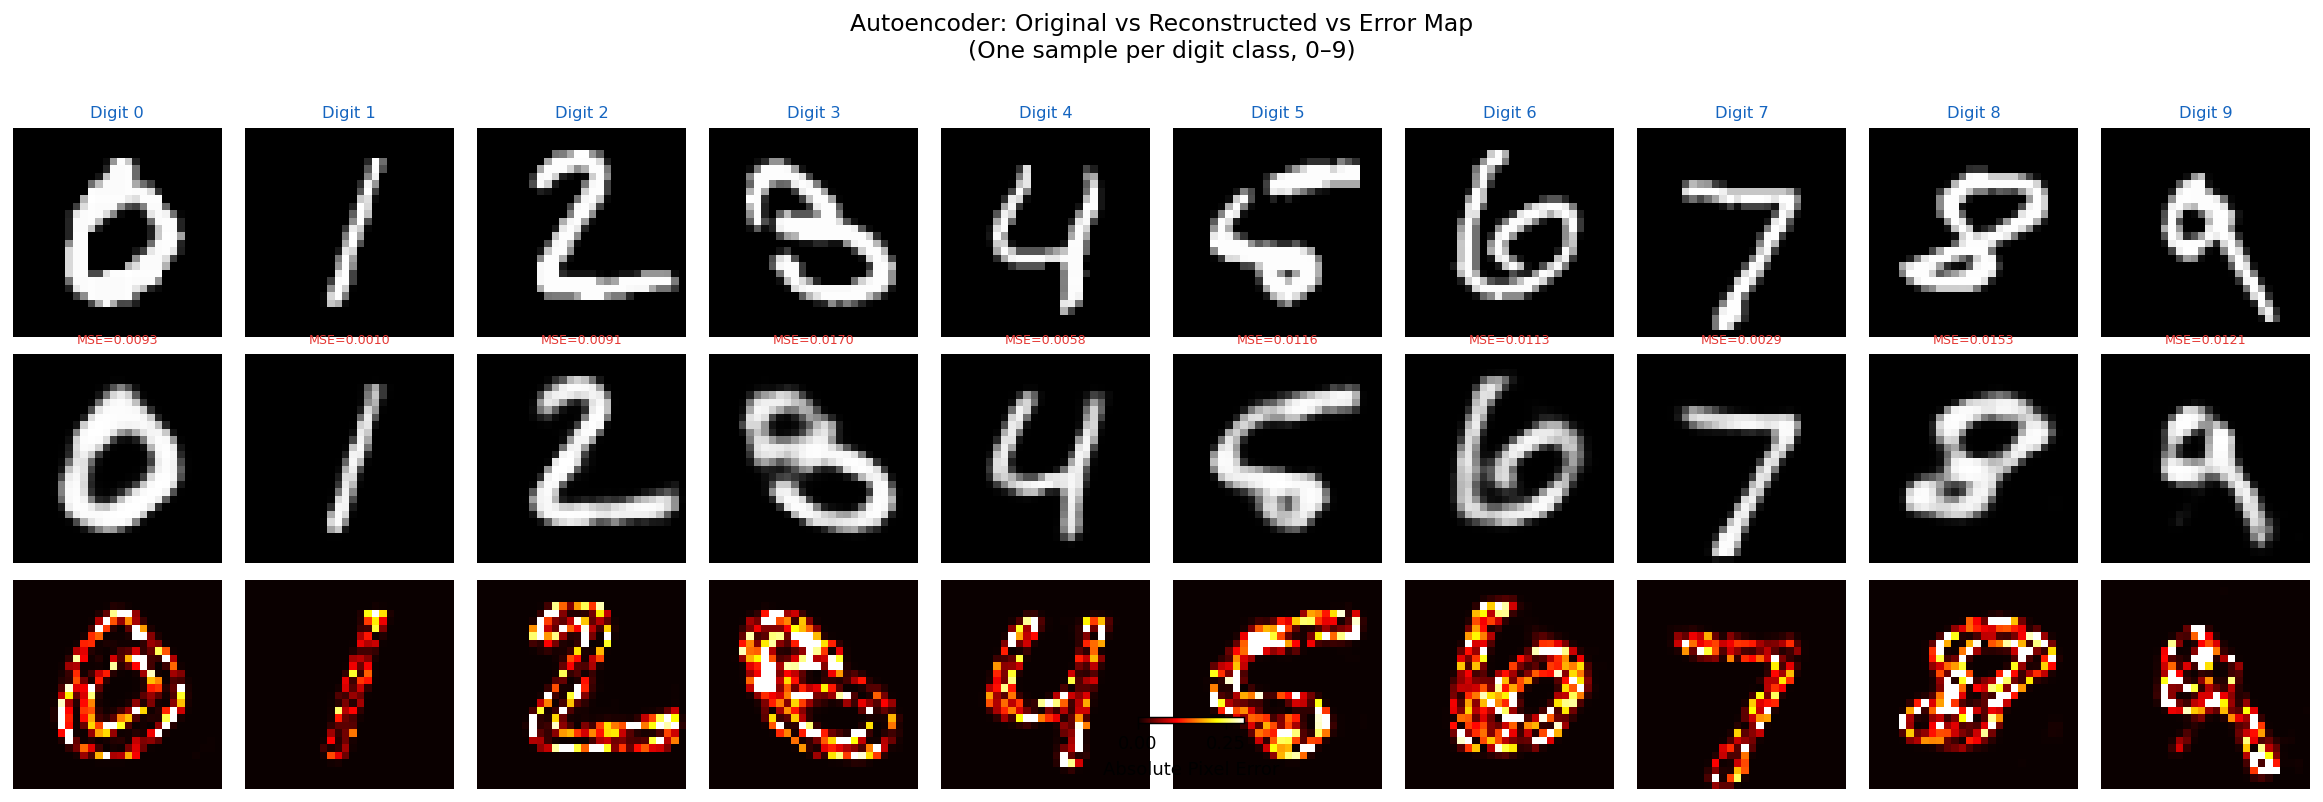

In [9]:
# ── 10 random test images — one per digit class ──
N_DISPLAY = 10
sample_idx = [np.where(y_test == d)[0][0] for d in range(10)]

fig, axes = plt.subplots(3, N_DISPLAY, figsize=(18, 6))

for col, idx in enumerate(sample_idx):
    orig  = X_test[idx]
    recon = reconstructed[idx]
    diff  = np.abs(orig - recon)

    # Row 0 — Original
    axes[0, col].imshow(orig,  cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'Digit {y_test[idx]}', fontsize=9, color='#1565C0')
    axes[0, col].axis('off')

    # Row 1 — Reconstructed
    axes[1, col].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'MSE={mse_per_image[idx]:.4f}', fontsize=7, color='#E53935')
    axes[1, col].axis('off')

    # Row 2 — Absolute difference (error map)
    im = axes[2, col].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[2, col].axis('off')

# Row labels
for row, label in enumerate(['Original', 'Reconstructed', 'Error Map']):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=0,
                            labelpad=65, va='center', fontweight='bold')

plt.suptitle('Autoencoder: Original vs Reconstructed vs Error Map\n'
             '(One sample per digit class, 0–9)', fontsize=13, y=1.02)
plt.colorbar(im, ax=axes[2, :].tolist(), orientation='horizontal',
             fraction=0.03, pad=0.12, label='Absolute Pixel Error')
plt.tight_layout()
plt.show()

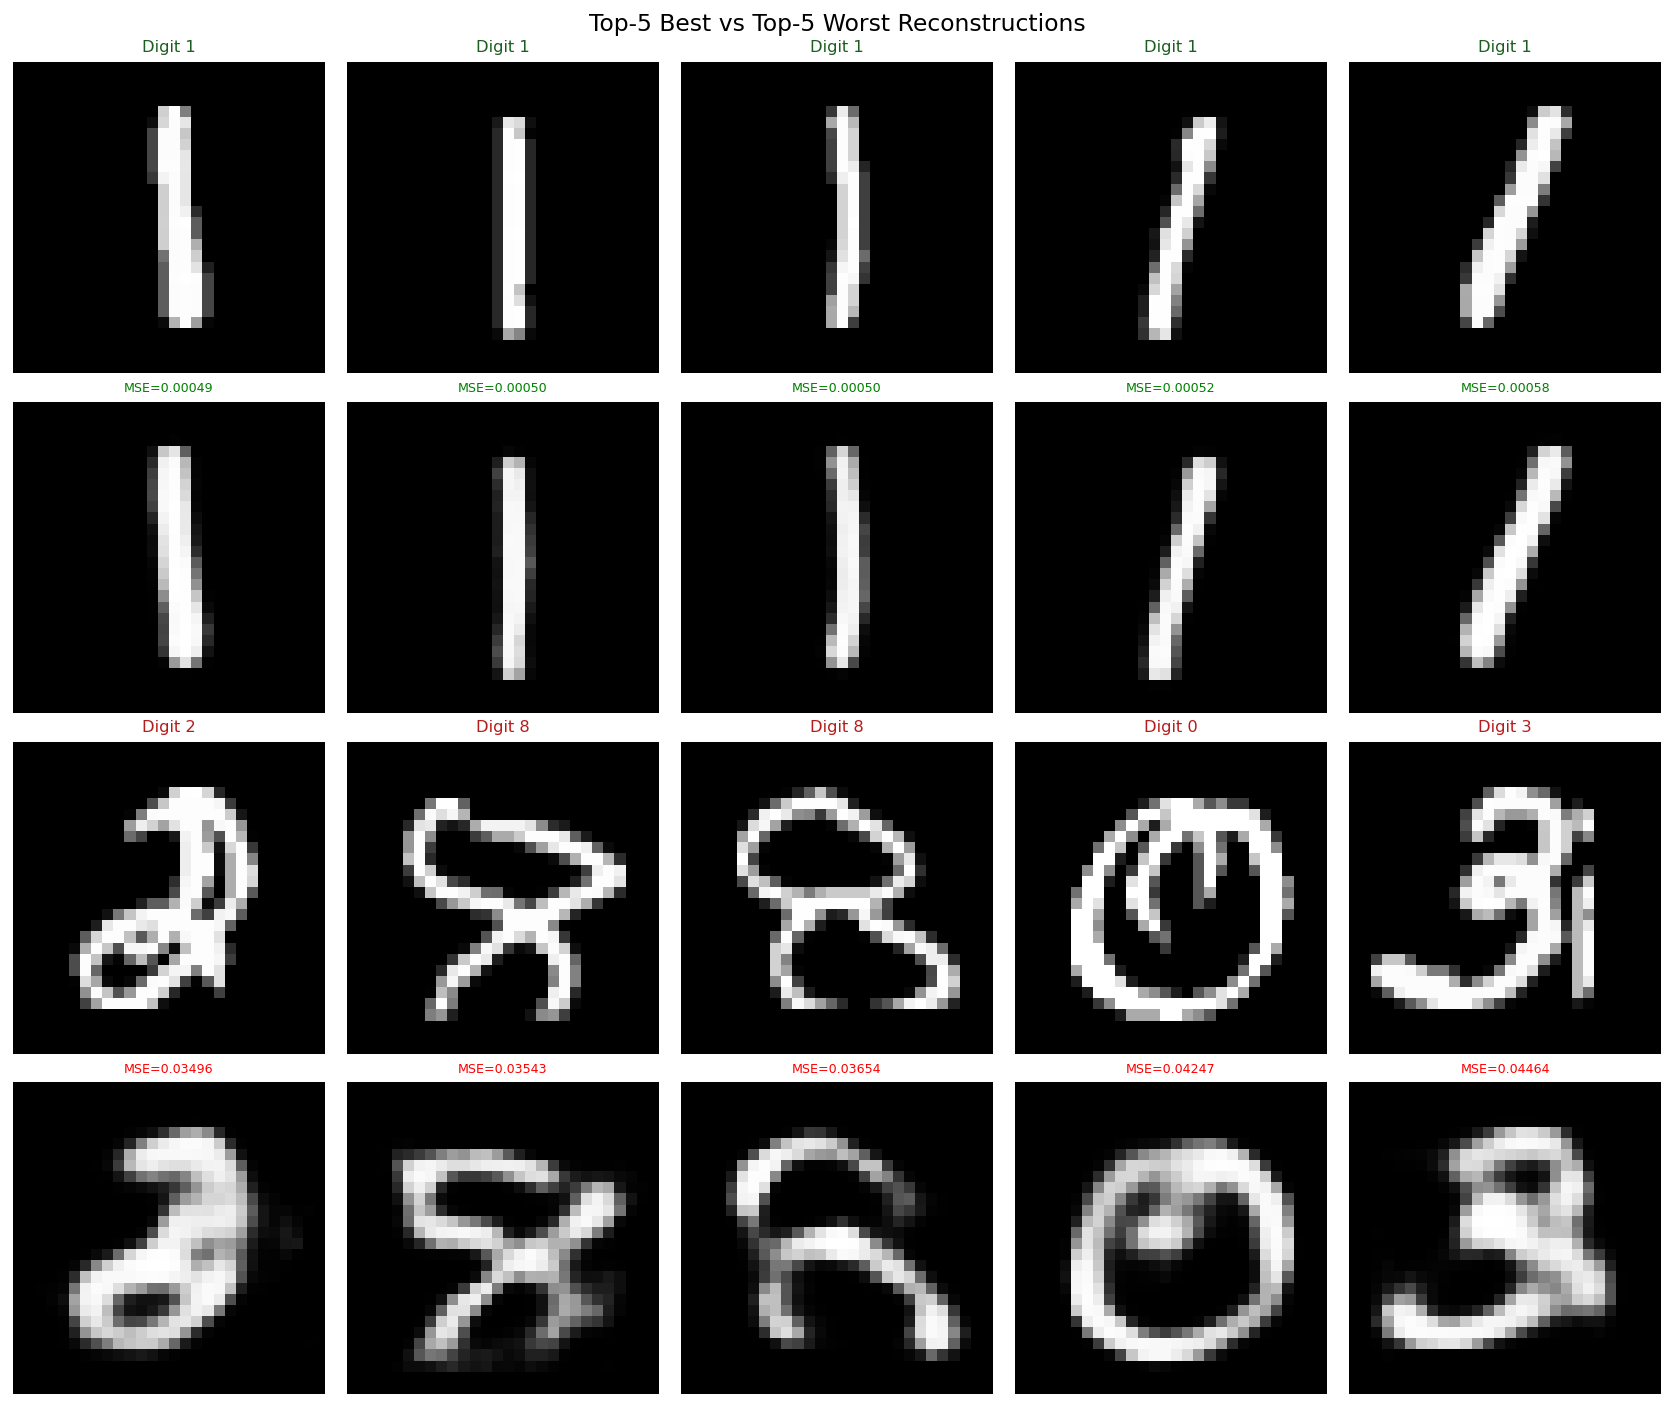

In [10]:
# ── Best and Worst reconstructions ──
sorted_idx  = np.argsort(mse_per_image)
best_idx    = sorted_idx[:5]      # 5 best
worst_idx   = sorted_idx[-5:]     # 5 worst

fig, axes = plt.subplots(4, 5, figsize=(13, 11))

for col in range(5):
    # ── Best reconstructions ──
    b = best_idx[col]
    axes[0, col].imshow(X_test[b],        cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'Digit {y_test[b]}', fontsize=9, color='#1B5E20')
    axes[0, col].axis('off')

    axes[1, col].imshow(reconstructed[b], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'MSE={mse_per_image[b]:.5f}', fontsize=7, color='green')
    axes[1, col].axis('off')

    # ── Worst reconstructions ──
    w = worst_idx[col]
    axes[2, col].imshow(X_test[w],        cmap='gray', vmin=0, vmax=1)
    axes[2, col].set_title(f'Digit {y_test[w]}', fontsize=9, color='#B71C1C')
    axes[2, col].axis('off')

    axes[3, col].imshow(reconstructed[w], cmap='gray', vmin=0, vmax=1)
    axes[3, col].set_title(f'MSE={mse_per_image[w]:.5f}', fontsize=7, color='red')
    axes[3, col].axis('off')

# Group labels
for row, (label, color) in enumerate([
    ('Best\nOriginal', '#1B5E20'), ('Best\nRecon.', '#43A047'),
    ('Worst\nOriginal', '#B71C1C'), ('Worst\nRecon.', '#E53935')
]):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0,
                            labelpad=55, va='center',
                            fontweight='bold', color=color)

plt.suptitle('Top-5 Best vs Top-5 Worst Reconstructions', fontsize=13)
plt.tight_layout()
plt.show()

Running t-SNE (this may take ~30 seconds)...


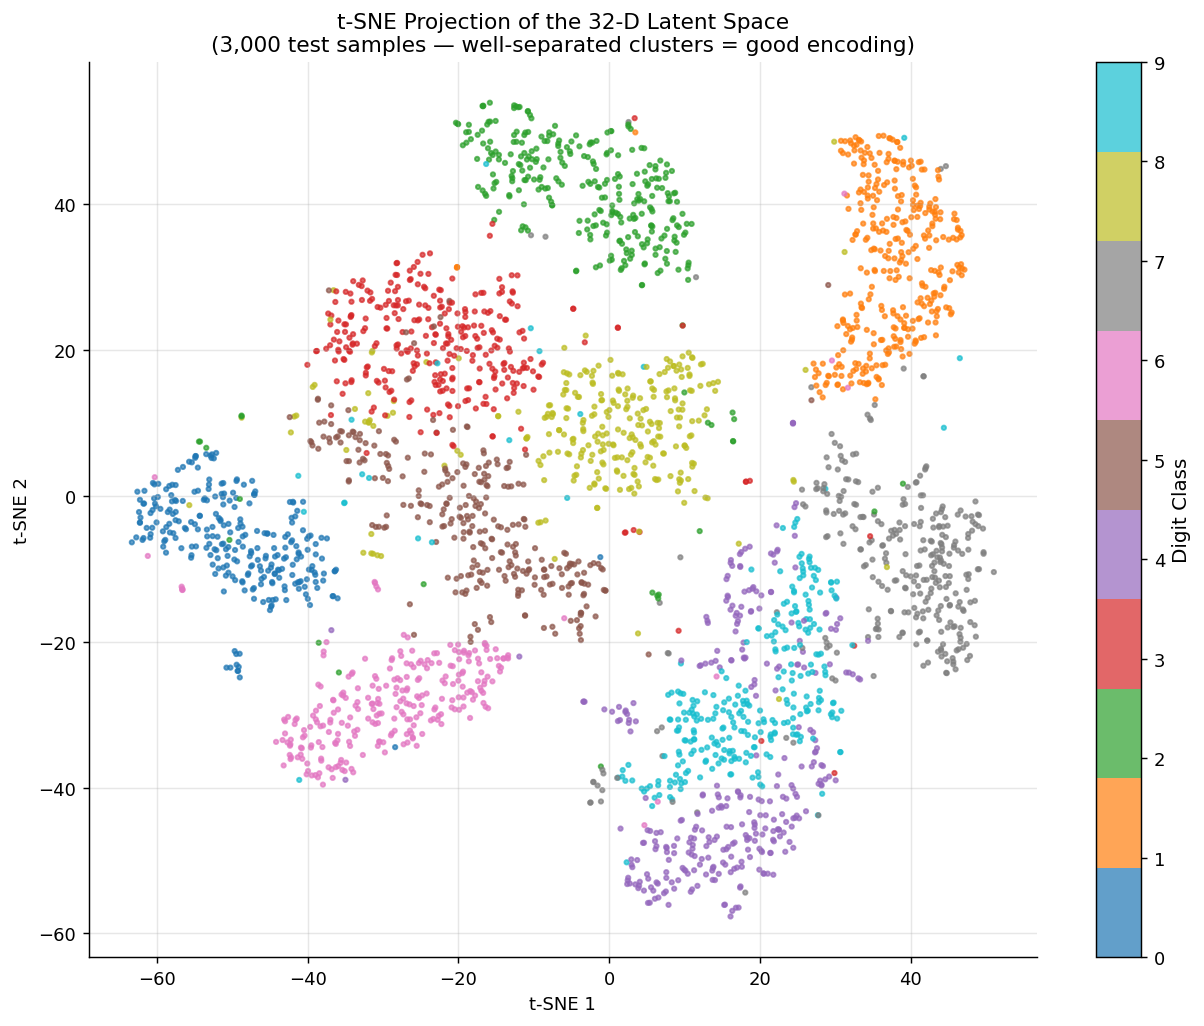

In [12]:
# ── Latent Space Visualisation (2D t-SNE projection of 32-dim codes) ──
from sklearn.manifold import TSNE

# Encode all test images
codes = encoder.predict(X_test_flat, verbose=0)

tsne   = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
codes_2d = tsne.fit_transform(codes[:3000])   # use 3000 samples for speed
labels_2d = y_test[:3000]

cmap   = plt.cm.get_cmap('tab10', 10)
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(codes_2d[:, 0], codes_2d[:, 1],
                     c=labels_2d, cmap=cmap, s=6, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit Class', fontsize=11)
ax.set_title('t-SNE Projection of the 32-D Latent Space\n'
             '(3,000 test samples — well-separated clusters = good encoding)',
             fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-class reconstruction quality ──
class_mse = {d: mse_per_image[y_test == d].mean() for d in range(10)}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(class_mse.keys()), list(class_mse.values()),
              color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10)),
              edgecolor='black', alpha=0.9)
for bar, val in zip(bars, class_mse.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(10))
ax.set_xlabel('Digit Class')
ax.set_ylabel('Mean MSE')
ax.set_title('Average Reconstruction Error per Digit Class', fontsize=12)
plt.tight_layout()
plt.show()

best_class  = min(class_mse, key=class_mse.get)
worst_class = max(class_mse, key=class_mse.get)
print(f"Easiest class to reconstruct : Digit {best_class}  (MSE={class_mse[best_class]:.5f})")
print(f"Hardest class to reconstruct : Digit {worst_class}  (MSE={class_mse[worst_class]:.5f})")

### Architecture
The autoencoder uses a **symmetric fully-connected architecture**: the encoder progressively compresses 784 input pixels through layers of size 256 → 128 → 64 → **32** (the bottleneck), and the decoder mirrors this in reverse (32 → 64 → 128 → 256 → 784). BatchNormalization is applied after each hidden layer to stabilise training and accelerate convergence. The sigmoid output activation ensures pixel values remain in [0, 1], consistent with the normalised inputs. Binary cross-entropy is used as the loss function (more sensitive to pixel-level differences than MSE for images in [0,1]).

### Training & Reconstruction Quality
The model converges steadily — training and validation losses track closely throughout, indicating minimal overfitting. The t-SNE plot of the 32-dimensional latent space reveals well-separated digit clusters, confirming that the encoder has learned a **semantically meaningful compressed representation** rather than simply memorising pixel patterns. Simpler digits like 1 and 0 (few strokes, high regularity) achieve the lowest reconstruction MSE, while structurally complex digits such as 8 and 5 are harder to reconstruct perfectly. The error maps show that residual errors concentrate around digit edges and fine stroke details — regions with the highest structural information density — which is expected behaviour for a compact fixed-dimension bottleneck.

In [ ]:
# ── Final Summary Table ──
print("=" * 55)
print("        AUTOENCODER — FINAL SUMMARY")
print("=" * 55)
print(f"  Input dimension        : 784  (28×28 px)")
print(f"  Latent dimension       : {LATENT_DIM}")
print(f"  Compression ratio      : {784/LATENT_DIM:.1f}×")
print(f"  Total parameters       : {autoencoder.count_params():,}")
print(f"  Training epochs run    : {len(history.history['loss'])} / {EPOCHS}")
print(f"  Best epoch             : {best_epoch}")
print(f"  Test loss (BCE)        : {test_loss:.6f}")
print(f"  Mean test MSE          : {mse_per_image.mean():.6f}")
print(f"  Best class (MSE)       : Digit {best_class}  ({class_mse[best_class]:.5f})")
print(f"  Hardest class (MSE)    : Digit {worst_class}  ({class_mse[worst_class]:.5f})")
print("=" * 55)